# 6.6 Q1: Iris Multi-class Classification

**Objective:** Classify all 3 iris species

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

# Use THIS notebook's folder paths
NOTEBOOK_DIR = os.getcwd()
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, 'datasets')
OUTPUTS_DIR = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [2]:
# Load and Prepare Data
df = pd.read_csv(os.path.join(DATASETS_DIR, 'iris.csv'))
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df['species'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")

Accuracy: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



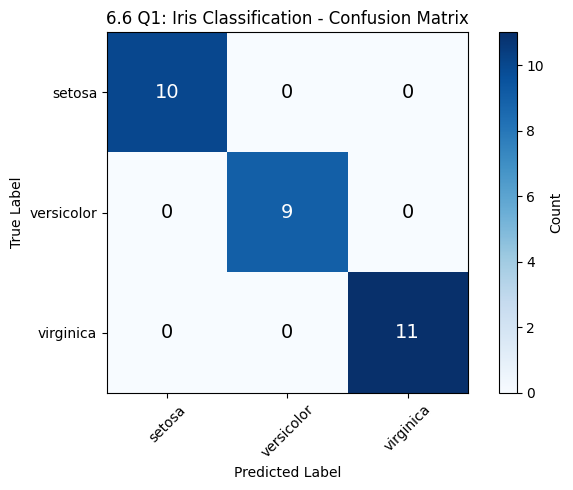

✅ Saved to: /home/z/my-project/ML-Labs-1-2-Final/02-Logistic-Regression/outputs/6.6_Q1_Iris_Classification.png


In [3]:
# Confusion Matrix - Save to outputs/
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('6.6 Q1: Iris Classification - Confusion Matrix')
plt.colorbar(label='Count')
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=14)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '6.6_Q1_Iris_Classification.png'), dpi=120)
plt.show()
print(f"✅ Saved to: {OUTPUTS_DIR}/6.6_Q1_Iris_Classification.png")